# 09_hfacs_cluster_analysis

This notebook analyzes relationships between HFACS classifications and
unsupervised text clusters. The goal is to identify which human-factor
categories dominate specific narrative themes and operational patterns.

This cross-analysis helps reveal systemic issues, recurring human-factor
contributors, and cluster-level risk signatures.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/processed/asrs_clustered_3yrs.csv")
df[["cluster",
    "HFACS_unsafe_acts",
    "HFACS_preconditions",
    "HFACS_unsafe_supervision",
    "HFACS_organizational_influences"]].head()

C:\Users\jenny\AppData\Local\Temp\ipykernel_10344\1116221191.py:1: DtypeWarning: Columns (7,8,15,19,20,38,39,40,41,42,43,44,45,46,47,48,49,50,59,63,78,79,81,82,83,86,89,99,100,110,111,123) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/asrs_clustered_3yrs.csv")


,cluster,HFACS_unsafe_acts,HFACS_preconditions,HFACS_unsafe_supervision,HFACS_organizational_influences
0,5,False,False,False,False
1,1,True,False,False,False
2,1,False,True,False,False
3,1,False,False,False,False
4,1,False,False,False,False


In [6]:
hfacs_long = df.melt(
    id_vars=["cluster"],
    value_vars=[
        "HFACS_unsafe_acts",
        "HFACS_preconditions",
        "HFACS_unsafe_supervision",
        "HFACS_organizational_influences"
    ],
    var_name="HFACS_Level",
    value_name="value"
)

In [7]:
hfacs_counts = (
    hfacs_long.groupby(["cluster", "HFACS_Level"])
              .size()
              .reset_index(name="count")
)

hfacs_counts.head()

,cluster,HFACS_Level,count
0,0,HFACS_organizational_influences,1753
1,0,HFACS_preconditions,1753
2,0,HFACS_unsafe_acts,1753
3,0,HFACS_unsafe_supervision,1753
4,1,HFACS_organizational_influences,5107


In [9]:
heatmap_data = hfacs_counts.pivot(
    index="HFACS_Level",
    columns="cluster",
    values="count"
).fillna(0)

heatmap_data

cluster,0,1,2,3,4,5,6,7,8,9,10,11
HFACS_Level,,,,,,,,,,,,
HFACS_organizational_influences,1753,5107,769,467,1455,1457,874,1491,879,1405,461,417
HFACS_preconditions,1753,5107,769,467,1455,1457,874,1491,879,1405,461,417
HFACS_unsafe_acts,1753,5107,769,467,1455,1457,874,1491,879,1405,461,417
HFACS_unsafe_supervision,1753,5107,769,467,1455,1457,874,1491,879,1405,461,417


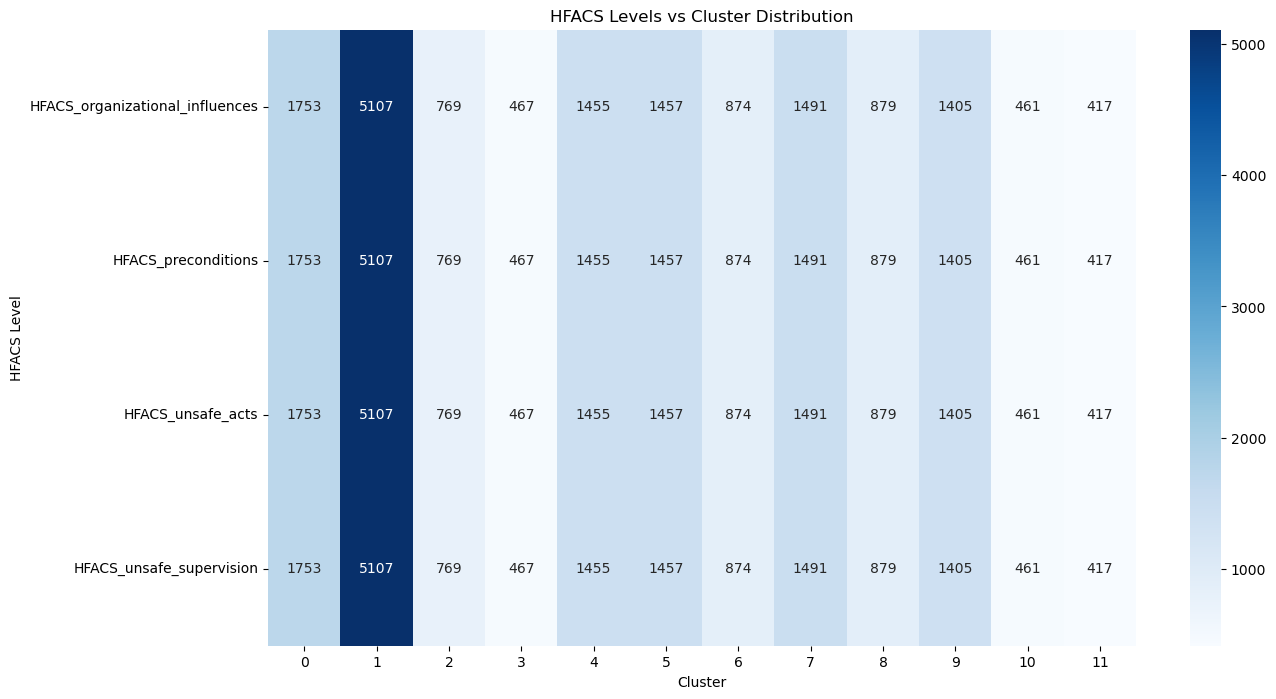

In [10]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    annot=True,
    fmt=".0f"
)

plt.title("HFACS Levels vs Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("HFACS Level")
plt.show()

In [11]:
hfacs_counts.to_csv(
    "../data/processed/hfacs_cluster_counts.csv",
    index=False
)

print("Saved HFACS × Cluster analysis table.")

Saved HFACS × Cluster analysis table.
